# Automatic Game Balancing with Top Trumps

## Case Study: Multi-Objective Optimization for Game Design

### Problem Definition

**Top Trumps** ist ein Kartenspiel, bei dem Spieler ihre Karten anhand von Kategorie-Werten vergleichen.

**Optimierungsaufgabe:**
- **Entscheidungsvariablen:** Deck als Vektor $x \in \mathbb{R}^{K \cdot L}$ mit K=22 Karten und L=4 Kategorien → 88 Parameter
- **Wertebereich:** $x_i \in [1, 10]$

**Ziele (zu maximieren):**
1. **Fairness** $f_1(x)$: Win-Rate des geschickteren Spielers p4 (sollte > 50% sein)
2. **Excitement** $f_2(x)$: Durchschnittliche Anzahl der "Trick Changes" (Wechsel des führenden Spielers)

**Output dieses Projekts:**
- Approximierte Pareto-Front
- Quality Indicator (Hypervolume)
- Interpretation: Was macht ein Deck fair vs. spannend?

---

### Notebook-Struktur (3 Notebooks)

1. **01_setup_and_exploration.ipynb** (dieses Notebook)
   - Setup & Reproduzierbarkeit
   - Simulation Engine
   - Sanity Checks

2. **02_optimization.ipynb**
   - Pymoo Problem-Wrapper
   - NSGA-II Optimierung
   - Validation mit R=1000

3. **03_analysis.ipynb**
   - Quality Indicators
   - Deck-Analyse
   - Export & Fazit

---

## 1. Setup & Reproduzierbarkeit

In [1]:
%pip install numpy pymoo pandas matplotlib seaborn tqdm joblib --quiet


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [3]:
SEED = 42
K = 22
L = 4
XL = 1.0
XU = 10.0
R_EVAL_FAST = 500  # Erhöht von 100 für stabilere Schätzungen
R_EVAL_FINAL = 1000

CONFIG = {
    "seed": SEED,
    "K": K,
    "L": L,
    "n_var": K * L,
    "xl": XL,
    "xu": XU,
    "R_eval_fast": R_EVAL_FAST,
    "R_eval_final": R_EVAL_FINAL
}

print(f"Problem Configuration:")
print(f"  Karten (K): {K}")
print(f"  Kategorien (L): {L}")
print(f"  Entscheidungsvariablen: {K * L}")
print(f"  Wertebereich: [{XL}, {XU}]")
print(f"  R_eval_fast: {R_EVAL_FAST}")
print(f"  Seed: {SEED}")

Problem Configuration:
  Karten (K): 22
  Kategorien (L): 4
  Entscheidungsvariablen: 88
  Wertebereich: [1.0, 10.0]
  R_eval_fast: 500
  Seed: 42


In [4]:
def set_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)

set_seeds(SEED)
print(f"Seeds gesetzt auf {SEED}")

Seeds gesetzt auf 42


In [5]:
RESULTS_DIR = Path("results")
PLOTS_DIR = Path("plots")

RESULTS_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

print(f"Ergebnis-Verzeichnis: {RESULTS_DIR.absolute()}")
print(f"Plot-Verzeichnis: {PLOTS_DIR.absolute()}")

Ergebnis-Verzeichnis: /Users/tim.strauss/ODM/odm_sheet1/case-study/TimsExperiments/results
Plot-Verzeichnis: /Users/tim.strauss/ODM/odm_sheet1/case-study/TimsExperiments/plots


---

## 2. Simulation Engine (TopTrumpsSimulation)

Die Simulation basiert auf dem bereitgestellten Code aus `top-trumps.ipynb`:

- **p0 (weniger geschickt):** Wählt die Kategorie mit dem höchsten normalisierten Wert auf seiner Karte
- **p4 (geschickter):** Berechnet exakte Gewinnwahrscheinlichkeit basierend auf verbleibenden Karten

In [6]:
from simulation import TopTrumpsSimulation

In [7]:
def evaluate_deck(sim, deck, R):
    sim.set_deck(deck)
    
    win_rates = []
    trick_changes_list = []
    p4_tricks_list = []
    
    for _ in range(R):
        result = sim.simulate_game()
        win_rates.append(1 if result['p4_won'] else 0)
        trick_changes_list.append(result['trick_changes'])
        p4_tricks_list.append(result['p4_tricks'])
    
    return {
        "win_rate": np.mean(win_rates),
        "win_rate_std": np.std(win_rates),
        "trick_changes": np.mean(trick_changes_list),
        "trick_changes_std": np.std(trick_changes_list),
        "p4_tricks_mean": np.mean(p4_tricks_list),
        "p4_tricks_std": np.std(p4_tricks_list),
        "raw_win_rates": win_rates,
        "raw_trick_changes": trick_changes_list
    }

In [8]:
sim = TopTrumpsSimulation(num_cards=K, num_categories=L)
print(f"Simulation erstellt: {K} Karten, {L} Kategorien")

Simulation erstellt: 22 Karten, 4 Kategorien


---

## 3. Sanity Checks

### 3.1 Plausibilitätsprüfung: Verschiedene zufällige Decks

In [9]:
set_seeds(SEED)

test_decks = [
    ("Random Deck 1", np.random.uniform(XL, XU, K * L)),
    ("Random Deck 2", np.random.uniform(XL, XU, K * L)),
    ("Random Deck 3", np.random.uniform(XL, XU, K * L)),
    ("Uniform Low Variance", np.random.uniform(4.5, 5.5, K * L)),
    ("High Variance", np.random.uniform(1, 10, K * L))
]

results_df = []
for name, deck in test_decks:
    metrics = evaluate_deck(sim, deck, R=500)
    results_df.append({
        "Deck": name,
        "Win Rate": f"{metrics['win_rate']:.1%}",
        "Win Rate (raw)": metrics['win_rate'],
        "Trick Changes": f"{metrics['trick_changes']:.2f}",
        "Trick Changes (raw)": metrics['trick_changes'],
        "p4 Tricks": f"{metrics['p4_tricks_mean']:.2f}"
    })

results_table = pd.DataFrame(results_df)
print("\n=== Sanity Check: Verschiedene Decks (R=500) ===")
print(results_table[["Deck", "Win Rate", "Trick Changes", "p4 Tricks"]].to_string(index=False))


=== Sanity Check: Verschiedene Decks (R=500) ===
                Deck Win Rate Trick Changes p4 Tricks
       Random Deck 1    52.4%          1.81      5.68
       Random Deck 2    52.8%          1.92      5.77
       Random Deck 3    51.0%          1.73      5.64
Uniform Low Variance    55.0%          2.48      5.87
       High Variance    55.4%          2.05      6.00


### 3.2 Noisiness-Test: Gleiches Deck, mehrere Evaluierungen

Wichtig für das Verständnis: Die Metriken sind stochastisch aufgrund des Shufflings und der Startspieler-Wahl.

In [10]:
set_seeds(SEED)
fixed_deck = np.random.uniform(XL, XU, K * L)

noise_results = []
for run in range(10):
    metrics = evaluate_deck(sim, fixed_deck, R=200)
    noise_results.append({
        "Run": run + 1,
        "Win Rate": metrics['win_rate'],
        "Trick Changes": metrics['trick_changes']
    })

noise_df = pd.DataFrame(noise_results)

print("\n=== Noisiness-Test: Gleiches Deck, 10 unabhängige Evaluierungen (R=200 je) ===")
print(f"Win Rate      - Mean: {noise_df['Win Rate'].mean():.1%}, Std: {noise_df['Win Rate'].std():.3f}")
print(f"Trick Changes - Mean: {noise_df['Trick Changes'].mean():.2f}, Std: {noise_df['Trick Changes'].std():.3f}")


=== Noisiness-Test: Gleiches Deck, 10 unabhängige Evaluierungen (R=200 je) ===
Win Rate      - Mean: 52.7%, Std: 0.027
Trick Changes - Mean: 1.81, Std: 0.066


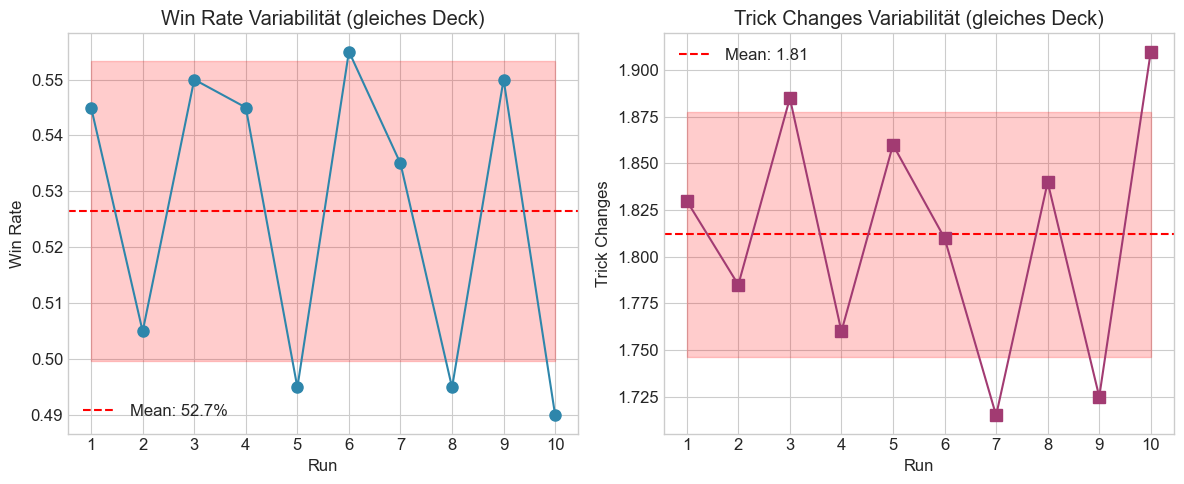


→ Plot gespeichert: plots/noisiness_test.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
ax1.errorbar(
    range(1, 11), 
    noise_df['Win Rate'], 
    fmt='o-', 
    capsize=5,
    markersize=8,
    color='#2E86AB'
)
ax1.axhline(noise_df['Win Rate'].mean(), color='red', linestyle='--', label=f'Mean: {noise_df["Win Rate"].mean():.1%}')
ax1.fill_between(
    range(1, 11),
    noise_df['Win Rate'].mean() - noise_df['Win Rate'].std(),
    noise_df['Win Rate'].mean() + noise_df['Win Rate'].std(),
    alpha=0.2, color='red'
)
ax1.set_xlabel('Run')
ax1.set_ylabel('Win Rate')
ax1.set_title('Win Rate Variabilität (gleiches Deck)')
ax1.legend()
ax1.set_xticks(range(1, 11))

ax2 = axes[1]
ax2.errorbar(
    range(1, 11), 
    noise_df['Trick Changes'], 
    fmt='s-', 
    capsize=5,
    markersize=8,
    color='#A23B72'
)
ax2.axhline(noise_df['Trick Changes'].mean(), color='red', linestyle='--', label=f'Mean: {noise_df["Trick Changes"].mean():.2f}')
ax2.fill_between(
    range(1, 11),
    noise_df['Trick Changes'].mean() - noise_df['Trick Changes'].std(),
    noise_df['Trick Changes'].mean() + noise_df['Trick Changes'].std(),
    alpha=0.2, color='red'
)
ax2.set_xlabel('Run')
ax2.set_ylabel('Trick Changes')
ax2.set_title('Trick Changes Variabilität (gleiches Deck)')
ax2.legend()
ax2.set_xticks(range(1, 11))

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'noisiness_test.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n→ Plot gespeichert: {PLOTS_DIR / 'noisiness_test.png'}")

### 3.3 Visualisierung: Win Rate vs Trick Changes Landschaft

Explorative Analyse: Wie sieht der Objective Space bei zufälligen Decks aus?

In [12]:
set_seeds(SEED)

n_random_samples = 100
exploration_results = []

print(f"Generiere {n_random_samples} zufällige Decks...")
for i in range(n_random_samples):
    deck = np.random.uniform(XL, XU, K * L)
    metrics = evaluate_deck(sim, deck, R=100)
    exploration_results.append({
        "win_rate": metrics['win_rate'],
        "trick_changes": metrics['trick_changes']
    })
    if (i + 1) % 20 == 0:
        print(f"  {i + 1}/{n_random_samples} fertig")

exploration_df = pd.DataFrame(exploration_results)
print("Done!")

Generiere 100 zufällige Decks...
  20/100 fertig
  40/100 fertig
  60/100 fertig
  80/100 fertig
  100/100 fertig
Done!


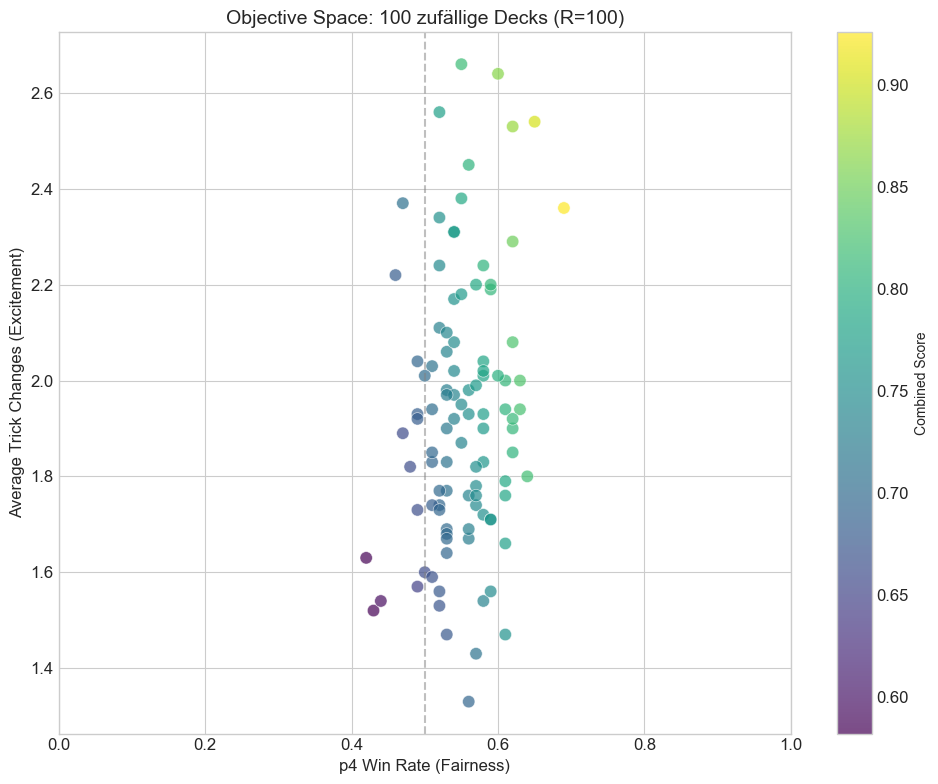


→ Plot gespeichert: plots/objective_space_exploration.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    exploration_df['win_rate'],
    exploration_df['trick_changes'],
    c=exploration_df['win_rate'] + exploration_df['trick_changes'] / 10,
    cmap='viridis',
    s=80,
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5
)

ax.set_xlabel('p4 Win Rate (Fairness)', fontsize=12)
ax.set_ylabel('Average Trick Changes (Excitement)', fontsize=12)
ax.set_title(f'Objective Space: {n_random_samples} zufällige Decks (R=100)', fontsize=14)

ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='50% Win Rate')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Combined Score', fontsize=10)

ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'objective_space_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n→ Plot gespeichert: {PLOTS_DIR / 'objective_space_exploration.png'}")

In [14]:
print("\n=== Statistische Zusammenfassung der Exploration ===")
print(f"Win Rate:       Min={exploration_df['win_rate'].min():.1%}, Max={exploration_df['win_rate'].max():.1%}, Mean={exploration_df['win_rate'].mean():.1%}")
print(f"Trick Changes:  Min={exploration_df['trick_changes'].min():.2f}, Max={exploration_df['trick_changes'].max():.2f}, Mean={exploration_df['trick_changes'].mean():.2f}")
print(f"\n→ Beobachteter Wertebereich für Reference Point (Hypervolume):")
print(f"   Win Rate: [{exploration_df['win_rate'].min():.2f}, {exploration_df['win_rate'].max():.2f}]")
print(f"   Trick Changes: [{exploration_df['trick_changes'].min():.2f}, {exploration_df['trick_changes'].max():.2f}]")


=== Statistische Zusammenfassung der Exploration ===
Win Rate:       Min=42.0%, Max=69.0%, Mean=55.2%
Trick Changes:  Min=1.33, Max=2.66, Mean=1.93

→ Beobachteter Wertebereich für Reference Point (Hypervolume):
   Win Rate: [0.42, 0.69]
   Trick Changes: [1.33, 2.66]


---

## 4. Export für Notebook 2

Speichere die Konfiguration für die Optimierung.

In [15]:
CONFIG['exploration_stats'] = {
    'win_rate_range': [float(exploration_df['win_rate'].min()), float(exploration_df['win_rate'].max())],
    'trick_changes_range': [float(exploration_df['trick_changes'].min()), float(exploration_df['trick_changes'].max())]
}

config_path = RESULTS_DIR / 'config.json'
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)

print(f"Konfiguration gespeichert: {config_path}")
print(f"\n{json.dumps(CONFIG, indent=2)}")

Konfiguration gespeichert: results/config.json

{
  "seed": 42,
  "K": 22,
  "L": 4,
  "n_var": 88,
  "xl": 1.0,
  "xu": 10.0,
  "R_eval_fast": 500,
  "R_eval_final": 1000,
  "exploration_stats": {
    "win_rate_range": [
      0.42,
      0.69
    ],
    "trick_changes_range": [
      1.33,
      2.66
    ]
  }
}
